### Test voxel model generation

- Input:
    - A 3D model file in `.obj` format, which is generated by `Arbaro`.
- Output:
    - `.npy` file containing the voxel dielectric constant values of the tree model.
    - with/without leaves

- Installation:
    - `Arbaro`

- Parameters:
    - Detail parameters are listed in `tree_voxel_config.json`

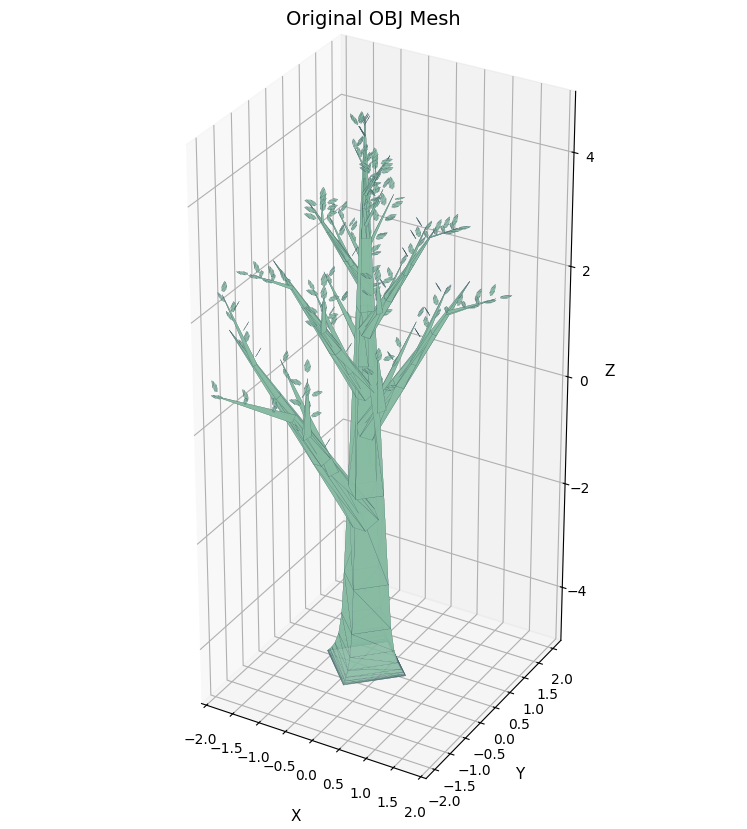

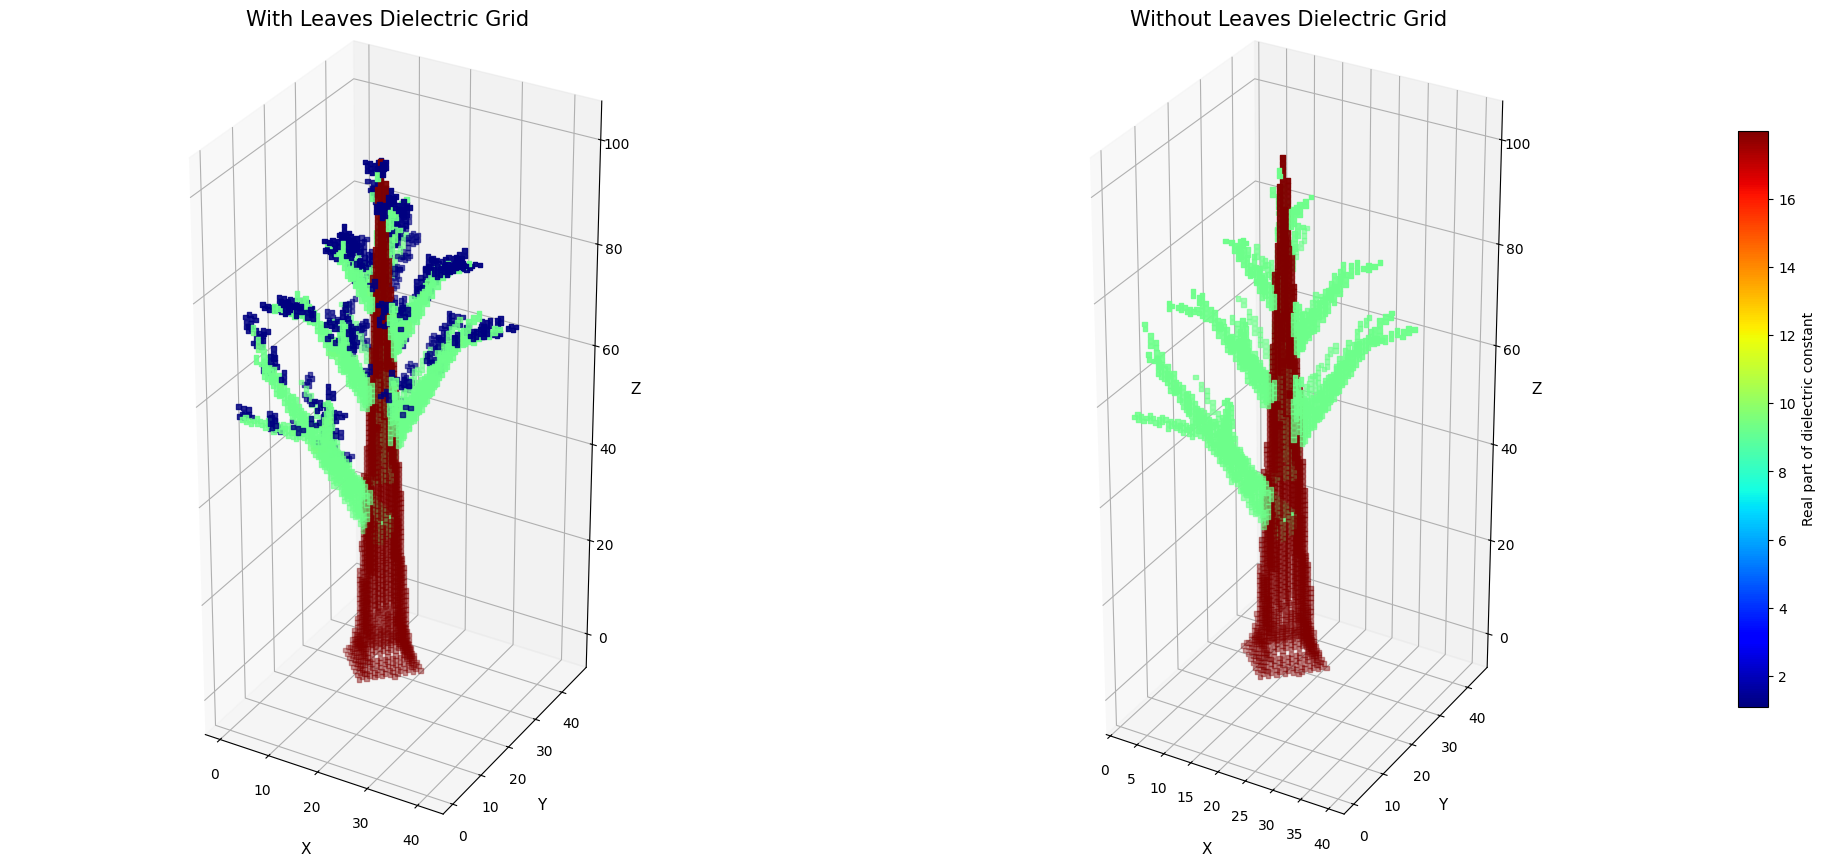

Loaded OBJ: /home/hsuyueh.chuang/Desktop/vscode/github/sar_research_note/tree-model-generation/Arbaro/test.obj
Original mesh: <trimesh.Trimesh(vertices.shape=(1941, 3), faces.shape=(1590, 3))>
Leaves mesh: <trimesh.Trimesh(vertices.shape=(1560, 3), faces.shape=(1170, 3))>
Trunk mesh: <trimesh.Trimesh(vertices.shape=(49, 3), faces.shape=(92, 3))>
Branches mesh: <trimesh.Trimesh(vertices.shape=(264, 3), faces.shape=(328, 3))>
Leaf mask grid shape: (43, 47, 101)
Trunk mask grid shape: (43, 47, 101)
Branch mask grid shape: (43, 47, 101)
With leaves dielectric grid shape: (43, 47, 101)
Without leaves dielectric grid shape: (43, 47, 101)
Output directory: /home/hsuyueh.chuang/Desktop/vscode/github/sar_research_note/tree-model-generation/output


In [47]:
from __future__ import annotations

import argparse
import json
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import trimesh
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


if "__file__" in globals():
    BASE_DIR = Path(__file__).resolve().parent
else:
    BASE_DIR = Path("/home/hsuyueh.chuang/Desktop/vscode/github/sar_research_note/tree-model-generation")
DEFAULT_CONFIG_PATH = BASE_DIR / "configs" / "tree_voxel_config.json"


@dataclass(slots=True)
class InputConfig:
    obj_path: Path


@dataclass(slots=True)
class OutputConfig:
    output_dir: Path
    with_leaves_voxel_file_name: str = "with_leaves_voxel.npy"
    without_leaves_voxel_file_name: str = "without_leaves_voxel.npy"
    save_npy: bool = True


@dataclass(slots=True)
class VoxelConfig:
    pitch: float = 0.1


@dataclass(slots=True)
class DisplayConfig:
    show_original_mesh: bool = True
    show_leaf_grid: bool = False
    show_branch_grid: bool = False


@dataclass(slots=True)
class GroupingConfig:
    leaves_keywords: tuple[str, ...] = ("leaves",)
    trunk_keywords: tuple[str, ...] = ("trunk",)
    branches_keywords: tuple[str, ...] = ("stem", "stems", "branch", "branches")


@dataclass(slots=True)
class DielectricConfig:
    enabled: bool = True
    frequency_ghz: float = 1.25
    epsilon_air: float = 1.0
    epsilon_leaf_real: float = 15.33
    epsilon_leaf_imag: float = 5.26
    sigma: float = 1.27
    leaf_volume_fraction: float = 0.01
    branch_volume_fraction: float = 0.3
    trunk_volume_fraction: float = 1.0
    branch_moisture_content: float = 0.3
    trunk_moisture_content: float = 0.5
    show_dielectric: bool = True


@dataclass(slots=True)
class TreeVoxelizerConfig:
    input: InputConfig
    output: OutputConfig
    voxel: VoxelConfig = field(default_factory=VoxelConfig)
    display: DisplayConfig = field(default_factory=DisplayConfig)
    grouping: GroupingConfig = field(default_factory=GroupingConfig)
    dielectric: DielectricConfig = field(default_factory=DielectricConfig)
    extra: dict[str, Any] = field(default_factory=dict)

    @classmethod
    def from_json(cls, config_path: Path) -> "TreeVoxelizerConfig":
        with config_path.open("r", encoding="utf-8") as handle:
            raw_config = json.load(handle)

        input_section = InputConfig(
            obj_path=Path(raw_config["input"]["obj_path"]).expanduser(),
        )
        output_raw = raw_config.get("output", {})
        output_section = OutputConfig(
            output_dir=Path(output_raw["output_dir"]).expanduser(),
            with_leaves_voxel_file_name=output_raw.get(
                "with_leaves_voxel_file_name",
                "with_leaves_voxel.npy",
            ),
            without_leaves_voxel_file_name=output_raw.get(
                "without_leaves_voxel_file_name",
                "without_leaves_voxel.npy",
            ),
            save_npy=output_raw.get("save_npy", True),
        )
        voxel_raw = raw_config.get("voxel", {})
        voxel_section = VoxelConfig(pitch=voxel_raw.get("pitch", 0.1))
        display_raw = raw_config.get("display", {})
        display_section = DisplayConfig(
            show_original_mesh=display_raw.get("show_original_mesh", True),
            show_leaf_grid=display_raw.get("show_leaf_grid", False),
            show_branch_grid=display_raw.get("show_branch_grid", False),
        )
        grouping_raw = raw_config.get("grouping", {})
        grouping_section = GroupingConfig(
            leaves_keywords=tuple(grouping_raw.get("leaves_keywords", ["leaves"])),
            trunk_keywords=tuple(grouping_raw.get("trunk_keywords", ["trunk"])),
            branches_keywords=tuple(
                grouping_raw.get(
                    "branches_keywords",
                    ["stem", "stems", "branch", "branches"],
                )
            ),
        )
        dielectric_raw = raw_config.get("dielectric", {})
        dielectric_section = DielectricConfig(
            enabled=dielectric_raw.get("enabled", True),
            frequency_ghz=dielectric_raw.get("frequency_ghz", 1.25),
            epsilon_air=dielectric_raw.get("epsilon_air", 1.0),
            epsilon_leaf_real=dielectric_raw.get("epsilon_leaf_real", 15.33),
            epsilon_leaf_imag=dielectric_raw.get("epsilon_leaf_imag", 5.26),
            sigma=dielectric_raw.get("sigma", 1.27),
            leaf_volume_fraction=dielectric_raw.get("leaf_volume_fraction", 0.01),
            branch_volume_fraction=dielectric_raw.get("branch_volume_fraction", 0.3),
            trunk_volume_fraction=dielectric_raw.get("trunk_volume_fraction", 1.0),
            branch_moisture_content=dielectric_raw.get("branch_moisture_content", 0.3),
            trunk_moisture_content=dielectric_raw.get("trunk_moisture_content", 0.5),
            show_dielectric=dielectric_raw.get("show_dielectric", True),
        )

        known_sections = {"input", "output", "voxel", "display", "grouping", "dielectric"}
        extra = {key: value for key, value in raw_config.items() if key not in known_sections}

        config = cls(
            input=input_section,
            output=output_section,
            voxel=voxel_section,
            display=display_section,
            grouping=grouping_section,
            dielectric=dielectric_section,
            extra=extra,
        )
        config.validate()
        return config

    def validate(self) -> None:
        if self.voxel.pitch <= 0:
            raise ValueError("voxel.pitch must be greater than 0")
        if self.dielectric.frequency_ghz <= 0:
            raise ValueError("dielectric.frequency_ghz must be greater than 0")
        for field_name in (
            "leaf_volume_fraction",
            "branch_volume_fraction",
            "trunk_volume_fraction",
        ):
            value = getattr(self.dielectric, field_name)
            if not 0 <= value <= 1:
                raise ValueError(f"dielectric.{field_name} must be between 0 and 1")
        if not self.input.obj_path.exists():
            raise FileNotFoundError(f"OBJ file not found: {self.input.obj_path}")


@dataclass(slots=True)
class TreeVoxelResult:
    original_mesh: trimesh.Trimesh
    leaves_mesh: trimesh.Trimesh
    trunk_mesh: trimesh.Trimesh
    branches_mesh: trimesh.Trimesh
    leaf_mask_grid: np.ndarray
    trunk_mask_grid: np.ndarray
    branch_mask_grid: np.ndarray
    with_leaves_grid: np.ndarray | None = None
    without_leaves_grid: np.ndarray | None = None


class TreeVoxelizer:
    def __init__(self, config: TreeVoxelizerConfig) -> None:
        self.config = config

    def run(self) -> TreeVoxelResult:
        obj_path = self.config.input.obj_path.resolve()
        original_mesh = self.load_mesh(obj_path)
        leaves_mesh, trunk_mesh, branches_mesh = self.load_grouped_meshes(obj_path)

        normalization_transform = self.build_normalization_transform(original_mesh)
        original_mesh = self.apply_transform(original_mesh, normalization_transform)
        leaves_mesh = self.apply_transform(leaves_mesh, normalization_transform)
        trunk_mesh = self.apply_transform(trunk_mesh, normalization_transform)
        branches_mesh = self.apply_transform(branches_mesh, normalization_transform)

        reference_voxel = self.voxelize_mesh(original_mesh, self.config.voxel.pitch)
        leaf_mask_grid = self.rasterize_to_reference_grid(leaves_mesh, reference_voxel)
        trunk_mask_grid = self.rasterize_to_reference_grid(trunk_mesh, reference_voxel)
        branch_mask_grid = self.rasterize_to_reference_grid(branches_mesh, reference_voxel)
        with_leaves_grid, without_leaves_grid = self.build_dielectric_grids(
            leaf_mask_grid=leaf_mask_grid,
            trunk_mask_grid=trunk_mask_grid,
            branch_mask_grid=branch_mask_grid,
        )

        result = TreeVoxelResult(
            original_mesh=original_mesh,
            leaves_mesh=leaves_mesh,
            trunk_mesh=trunk_mesh,
            branches_mesh=branches_mesh,
            leaf_mask_grid=leaf_mask_grid,
            trunk_mask_grid=trunk_mask_grid,
            branch_mask_grid=branch_mask_grid,
            with_leaves_grid=with_leaves_grid,
            without_leaves_grid=without_leaves_grid,
        )

        self.save_outputs(result)
        self.preview(result)
        self.log_summary(obj_path, result)
        return result

    def load_mesh(self, obj_path: Path) -> trimesh.Trimesh:
        scene_or_mesh = trimesh.load(obj_path)
        if isinstance(scene_or_mesh, trimesh.Scene):
            geometries = [geometry for geometry in scene_or_mesh.geometry.values()]
            if not geometries:
                raise ValueError(f"No geometry found in OBJ file: {obj_path}")
            return trimesh.util.concatenate(geometries)
        if not isinstance(scene_or_mesh, trimesh.Trimesh):
            raise TypeError(f"Unsupported trimesh type: {type(scene_or_mesh)!r}")
        return scene_or_mesh

    def load_grouped_meshes(
        self,
        obj_path: Path,
    ) -> tuple[trimesh.Trimesh, trimesh.Trimesh, trimesh.Trimesh]:
        vertices: list[tuple[float, float, float]] = []
        group_faces: dict[str, list[list[int]]] = {}
        current_group = "default"

        with obj_path.open("r", encoding="utf-8") as handle:
            for raw_line in handle:
                line = raw_line.strip()
                if not line or line.startswith("#"):
                    continue
                if line.startswith("v "):
                    _, x_coord, y_coord, z_coord = line.split(maxsplit=3)
                    vertices.append((float(x_coord), float(y_coord), float(z_coord)))
                    continue
                if line.startswith("g "):
                    current_group = line.split(maxsplit=1)[1].strip() or "default"
                    group_faces.setdefault(current_group, [])
                    continue
                if line.startswith("f "):
                    face_tokens = line.split()[1:]
                    face_indices = [int(token.split("/")[0]) - 1 for token in face_tokens]
                    if len(face_indices) < 3:
                        continue
                    triangulated_faces = [
                        [face_indices[0], face_indices[index], face_indices[index + 1]]
                        for index in range(1, len(face_indices) - 1)
                    ]
                    group_faces.setdefault(current_group, []).extend(triangulated_faces)

        leaves_faces: list[list[int]] = []
        trunk_faces: list[list[int]] = []
        branch_faces: list[list[int]] = []
        for group_name, faces in group_faces.items():
            normalized_name = group_name.lower()
            if any(keyword.lower() in normalized_name for keyword in self.config.grouping.leaves_keywords):
                leaves_faces.extend(faces)
            elif any(keyword.lower() in normalized_name for keyword in self.config.grouping.trunk_keywords):
                trunk_faces.extend(faces)
            else:
                branch_faces.extend(faces)

        return (
            self.build_submesh(vertices, leaves_faces, label="leaves"),
            self.build_submesh(vertices, trunk_faces, label="trunk"),
            self.build_submesh(vertices, branch_faces, label="branches"),
        )

    @staticmethod
    def build_submesh(
        vertices: list[tuple[float, float, float]],
        faces: list[list[int]],
        *,
        label: str,
    ) -> trimesh.Trimesh:
        if not faces:
            raise ValueError(f"No faces found for {label}")
        used_vertex_indices = sorted({index for face in faces for index in face})
        remap = {old_index: new_index for new_index, old_index in enumerate(used_vertex_indices)}
        submesh_vertices = np.asarray([vertices[index] for index in used_vertex_indices], dtype=float)
        submesh_faces = np.asarray(
            [[remap[index] for index in face] for face in faces],
            dtype=int,
        )
        return trimesh.Trimesh(vertices=submesh_vertices, faces=submesh_faces, process=False)

    @staticmethod
    def voxelize_mesh(mesh: trimesh.Trimesh, pitch: float) -> trimesh.voxel.VoxelGrid:
        return mesh.voxelized(pitch=pitch)

    @staticmethod
    def apply_transform(mesh: trimesh.Trimesh, transform: np.ndarray) -> trimesh.Trimesh:
        transformed_mesh = mesh.copy()
        transformed_mesh.apply_transform(transform)
        return transformed_mesh

    @staticmethod
    def build_normalization_transform(mesh: trimesh.Trimesh) -> np.ndarray:
        bounds = mesh.bounds
        bbox_center = (bounds[0] + bounds[1]) / 2.0
        translation_to_origin = trimesh.transformations.translation_matrix(-bbox_center)

        extents = bounds[1] - bounds[0]
        major_axis_index = int(np.argmax(extents))
        axis_vector = np.zeros(3, dtype=float)
        axis_vector[major_axis_index] = 1.0

        rotation_to_z = trimesh.geometry.align_vectors(axis_vector, np.array([0.0, 0.0, 1.0]))
        if rotation_to_z is None:
            rotation_to_z = np.eye(4)

        transformed_bounds = trimesh.transform_points(bounds, rotation_to_z @ translation_to_origin)
        transformed_center = (transformed_bounds[0] + transformed_bounds[1]) / 2.0
        recenter_transform = trimesh.transformations.translation_matrix(-transformed_center)
        return recenter_transform @ rotation_to_z @ translation_to_origin

    def rasterize_to_reference_grid(
        self,
        mesh: trimesh.Trimesh,
        reference_voxel: trimesh.voxel.VoxelGrid,
    ) -> np.ndarray:
        component_voxel = self.voxelize_mesh(mesh, self.config.voxel.pitch)
        reference_pitch = float(reference_voxel.pitch[0])
        reference_translation = np.asarray(reference_voxel.translation, dtype=float)
        component_translation = np.asarray(component_voxel.translation, dtype=float)
        offset = np.rint((component_translation - reference_translation) / reference_pitch).astype(int)
        aligned_indices = component_voxel.sparse_indices + offset

        grid = np.zeros(reference_voxel.shape, dtype=bool)
        max_shape = np.asarray(reference_voxel.shape, dtype=int)
        valid = np.all(aligned_indices >= 0, axis=1) & np.all(aligned_indices < max_shape, axis=1)
        valid_indices = aligned_indices[valid]
        if valid_indices.size:
            grid[valid_indices[:, 0], valid_indices[:, 1], valid_indices[:, 2]] = True
        return grid

    def build_dielectric_grids(
        self,
        leaf_mask_grid: np.ndarray,
        trunk_mask_grid: np.ndarray,
        branch_mask_grid: np.ndarray,
    ) -> tuple[np.ndarray | None, np.ndarray | None]:
        if not self.config.dielectric.enabled:
            return None, None

        with_leaves_grid = np.full(
            leaf_mask_grid.shape,
            complex(self.config.dielectric.epsilon_air, 0.0),
            dtype=np.complex128,
        )
        without_leaves_grid = np.full(
            leaf_mask_grid.shape,
            complex(self.config.dielectric.epsilon_air, 0.0),
            dtype=np.complex128,
        )

        leaf_fraction_grid = leaf_mask_grid.astype(np.float64) * self.config.dielectric.leaf_volume_fraction
        trunk_fraction_grid = trunk_mask_grid.astype(np.float64) * self.config.dielectric.trunk_volume_fraction
        branch_fraction_grid = branch_mask_grid.astype(np.float64) * self.config.dielectric.branch_volume_fraction

        occupied = np.argwhere(leaf_mask_grid | trunk_mask_grid | branch_mask_grid)
        for x_index, y_index, z_index in occupied:
            leaf_fraction = float(leaf_fraction_grid[x_index, y_index, z_index])
            if trunk_mask_grid[x_index, y_index, z_index]:
                wood_fraction = float(trunk_fraction_grid[x_index, y_index, z_index])
                moisture_content = self.config.dielectric.trunk_moisture_content
            elif branch_mask_grid[x_index, y_index, z_index]:
                wood_fraction = float(branch_fraction_grid[x_index, y_index, z_index])
                moisture_content = self.config.dielectric.branch_moisture_content
            else:
                wood_fraction = 0.0
                moisture_content = self.config.dielectric.branch_moisture_content

            with_leaves_grid[x_index, y_index, z_index] = self.epsilon_effective_air_leaf_branch(
                v_l=leaf_fraction,
                v_b=wood_fraction,
                moisture_content=moisture_content,
            )
            without_leaves_grid[x_index, y_index, z_index] = self.epsilon_effective_air_leaf_branch(
                v_l=0.0,
                v_b=wood_fraction,
                moisture_content=moisture_content,
            )

        return with_leaves_grid, without_leaves_grid

    def epsilon_air_leaf(self, v_l: float) -> complex:
        epsilon_leaf = complex(
            self.config.dielectric.epsilon_leaf_real,
            -self.config.dielectric.epsilon_leaf_imag,
        )
        epsilon_leaf_real = epsilon_leaf.real
        epsilon_leaf_imag = -epsilon_leaf.imag
        epsilon_leaf_abs_sq = abs(epsilon_leaf) ** 2

        denominator = 1 + (v_l / 3.0) * ((epsilon_leaf_real / epsilon_leaf_abs_sq) - 1)
        epsilon_al_real = (1 + (2 * v_l / 3.0) * (epsilon_leaf_real - 1)) / denominator
        epsilon_al_imag = (
            (v_l / 3.0) * epsilon_leaf_imag * (2 + epsilon_al_real / epsilon_leaf_abs_sq)
        ) / denominator
        return complex(epsilon_al_real, -epsilon_al_imag)

    def epsilon_wood(self, moisture_content: float) -> complex:
        frequency_ghz = self.config.dielectric.frequency_ghz
        sigma = self.config.dielectric.sigma

        epsilon_r = 1.7 - 0.74 * moisture_content + 6.16 * moisture_content**2
        v_fw = moisture_content * (0.55 * moisture_content - 0.076)
        v_b = 4.64 * moisture_content**2 / (1 + 7.36 * moisture_content**2)

        term_free_water = (
            4.9
            + 75 / (1 + 1j * frequency_ghz / 18.0)
            + 1j * 18.0 * sigma / frequency_ghz
        )
        term_bound_water = 2.9 + 55 / np.sqrt(1j * frequency_ghz / 0.18)
        return epsilon_r + v_fw * term_free_water + v_b * term_bound_water

    def epsilon_effective_air_leaf_branch(
        self,
        v_l: float,
        v_b: float,
        moisture_content: float,
    ) -> complex:
        epsilon_al = self.epsilon_air_leaf(v_l=v_l)
        epsilon_w = self.epsilon_wood(moisture_content=moisture_content)
        numerator = (epsilon_w - epsilon_al) * (epsilon_w + 5 * epsilon_al) * v_b
        denominator = 3 * (epsilon_w + epsilon_al) - 2 * (epsilon_w - epsilon_al) * v_b
        return epsilon_al + numerator / denominator

    def save_outputs(self, result: TreeVoxelResult) -> None:
        output_dir = self.config.output.output_dir.resolve()
        output_dir.mkdir(parents=True, exist_ok=True)
        if self.config.output.save_npy:
            if result.with_leaves_grid is not None:
                np.save(output_dir / self.config.output.with_leaves_voxel_file_name, result.with_leaves_grid)
            if result.without_leaves_grid is not None:
                np.save(
                    output_dir / self.config.output.without_leaves_voxel_file_name,
                    result.without_leaves_grid,
                )

    def preview(self, result: TreeVoxelResult) -> None:
        if self.config.display.show_original_mesh:
            self.show_mesh(result.original_mesh, title="Original OBJ Mesh")
        if self.config.display.show_leaf_grid:
            self.show_boolean_grid(result.leaf_mask_grid, title="Leaf Occupancy Grid")
        if self.config.display.show_branch_grid:
            self.show_boolean_grid(result.branch_mask_grid, title="Branch Occupancy Grid")
        if (
            self.config.dielectric.show_dielectric
            and result.with_leaves_grid is not None
            and result.without_leaves_grid is not None
        ):
            self.show_dielectric_comparison(
                with_leaves_grid=result.with_leaves_grid,
                without_leaves_grid=result.without_leaves_grid,
                with_title="With Leaves Dielectric Grid",
                without_title="Without Leaves Dielectric Grid",
            )

    @staticmethod
    def running_in_notebook() -> bool:
        return "__file__" not in globals()

    @staticmethod
    def set_axis_box_aspect_from_bounds(
        axis: Any,
        mins: np.ndarray,
        maxs: np.ndarray,
    ) -> None:
        extents = np.asarray(maxs, dtype=float) - np.asarray(mins, dtype=float)
        extents = np.where(extents <= 0, 1.0, extents)
        axis.set_box_aspect(extents)

    @staticmethod
    def show_mesh(mesh: trimesh.Trimesh, title: str) -> None:
        vertices = mesh.vertices
        faces = mesh.faces

        if not TreeVoxelizer.running_in_notebook():
            try:
                mesh.show()
                return
            except Exception as exc:
                print(f"trimesh viewer unavailable for {title}, falling back to matplotlib: {exc}")

        figure = plt.figure(figsize=(8, 8))
        axis = figure.add_subplot(projection="3d")
        face_vertices = vertices[faces]
        collection = Poly3DCollection(
            face_vertices,
            facecolor="#87bba2",
            edgecolor="#2f4858",
            linewidths=0.1,
            alpha=0.9,
        )
        axis.add_collection3d(collection)
        axis.set_xlim(vertices[:, 0].min(), vertices[:, 0].max())
        axis.set_ylim(vertices[:, 1].min(), vertices[:, 1].max())
        axis.set_zlim(vertices[:, 2].min(), vertices[:, 2].max())
        TreeVoxelizer.set_axis_box_aspect_from_bounds(
            axis,
            vertices.min(axis=0),
            vertices.max(axis=0),
        )
        axis.set_title(title, fontsize=14, pad=20)
        axis.set_xlabel("X", fontsize=11, labelpad=10)
        axis.set_ylabel("Y", fontsize=11, labelpad=10)
        axis.set_zlabel("Z", fontsize=11, labelpad=10)
        plt.tight_layout()
        plt.show()

    @staticmethod
    def show_boolean_grid(matrix: np.ndarray, title: str) -> None:
        figure = plt.figure(figsize=(9, 8))
        axis = figure.add_subplot(projection="3d")
        axis.voxels(matrix, edgecolor="k")
        TreeVoxelizer.set_axis_box_aspect_from_bounds(
            axis,
            np.array([0.0, 0.0, 0.0]),
            np.array(matrix.shape, dtype=float),
        )
        axis.set_title(title, fontsize=14, pad=20)
        axis.set_xlabel("X", fontsize=11, labelpad=10)
        axis.set_ylabel("Y", fontsize=11, labelpad=10)
        axis.set_zlabel("Z", fontsize=11, labelpad=10)
        figure.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.9)
        plt.show()

    @staticmethod
    def show_dielectric_comparison(
        with_leaves_grid: np.ndarray,
        without_leaves_grid: np.ndarray,
        with_title: str,
        without_title: str,
    ) -> None:
        with_air_mask = np.isclose(with_leaves_grid.real, 1.0) & np.isclose(with_leaves_grid.imag, 0.0)
        without_air_mask = np.isclose(without_leaves_grid.real, 1.0) & np.isclose(
            without_leaves_grid.imag,
            0.0,
        )
        with_occupied_mask = ~with_air_mask
        without_occupied_mask = ~without_air_mask

        if not np.any(with_occupied_mask) and not np.any(without_occupied_mask):
            print("No dielectric voxels to display.")
            return

        all_values: list[np.ndarray] = []
        if np.any(with_occupied_mask):
            all_values.append(with_leaves_grid.real[with_occupied_mask])
        if np.any(without_occupied_mask):
            all_values.append(without_leaves_grid.real[without_occupied_mask])

        shared_values = np.concatenate(all_values)
        vmin = float(shared_values.min())
        vmax = float(shared_values.max())
        if np.isclose(vmin, vmax):
            vmax = vmin + 1e-6

        normalizer = plt.Normalize(vmin=vmin, vmax=vmax)
        colormap = plt.cm.jet

        figure = plt.figure(figsize=(20, 9))
        left_axis = figure.add_subplot(1, 2, 1, projection="3d")
        right_axis = figure.add_subplot(1, 2, 2, projection="3d")

        for axis, grid, mask, title in (
            (left_axis, with_leaves_grid, with_occupied_mask, with_title),
            (right_axis, without_leaves_grid, without_occupied_mask, without_title),
        ):
            indices = np.argwhere(mask)
            if indices.size == 0:
                axis.set_title(f"{title}\n(no occupied voxels)")
                continue
            values = grid.real[mask]
            colors = colormap(normalizer(values))
            axis.scatter(
                indices[:, 0],
                indices[:, 1],
                indices[:, 2],
                c=colors,
                s=10,
                marker="s",
            )
            TreeVoxelizer.set_axis_box_aspect_from_bounds(
                axis,
                np.array([0.0, 0.0, 0.0]),
                np.array(grid.shape, dtype=float),
            )
            axis.set_title(title, fontsize=15, pad=24)
            axis.set_xlabel("X", fontsize=11, labelpad=10)
            axis.set_ylabel("Y", fontsize=11, labelpad=10)
            axis.set_zlabel("Z", fontsize=11, labelpad=10)

        colorbar_axis = figure.add_axes([0.92, 0.18, 0.015, 0.64])
        colorbar = figure.colorbar(
            plt.cm.ScalarMappable(norm=normalizer, cmap=colormap),
            cax=colorbar_axis,
        )
        colorbar.set_label("Real part of dielectric constant")
        figure.subplots_adjust(left=0.04, right=0.9, bottom=0.06, top=0.9, wspace=0.1)
        plt.show()

    def log_summary(self, obj_path: Path, result: TreeVoxelResult) -> None:
        print(f"Loaded OBJ: {obj_path}")
        print(f"Original mesh: {result.original_mesh}")
        print(f"Leaves mesh: {result.leaves_mesh}")
        print(f"Trunk mesh: {result.trunk_mesh}")
        print(f"Branches mesh: {result.branches_mesh}")
        print(f"Leaf mask grid shape: {result.leaf_mask_grid.shape}")
        print(f"Trunk mask grid shape: {result.trunk_mask_grid.shape}")
        print(f"Branch mask grid shape: {result.branch_mask_grid.shape}")
        if result.with_leaves_grid is not None:
            print(f"With leaves dielectric grid shape: {result.with_leaves_grid.shape}")
        if result.without_leaves_grid is not None:
            print(f"Without leaves dielectric grid shape: {result.without_leaves_grid.shape}")
        print(f"Output directory: {self.config.output.output_dir.resolve()}")


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Load an OBJ, build one common voxel lattice, and compare dielectric grids with and without leaves."
    )
    parser.add_argument(
        "--config",
        type=Path,
        default=DEFAULT_CONFIG_PATH,
        help=f"Path to the JSON config file. Default: {DEFAULT_CONFIG_PATH}",
    )
    if "__file__" in globals():
        return parser.parse_args()
    return parser.parse_known_args()[0]


def main() -> None:
    args = parse_args()
    config_path = args.config.expanduser().resolve()
    config = TreeVoxelizerConfig.from_json(config_path)
    TreeVoxelizer(config).run()


if __name__ == "__main__":
    main()
